In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings

warnings.filterwarnings("ignore")

In [ ]:
!pip -q install kagglehub
import kagglehub, os

path = kagglehub.dataset_download(
    "faresashraf1001/supermarket-sales"
)
print("Folder dataset:", path)
print("Daftar file:", os.listdir(path))

Using Colab cache for faster access to the 'supermarket-sales' dataset.
Folder dataset: /kaggle/input/supermarket-sales
Daftar file: ['SuperMarket Analysis.csv']


In [ ]:
df = pd.read_csv(f'{path}/SuperMarket Analysis.csv')

In [ ]:
# Persentase Margin Kotor Ditetapkan pada 4,7619% sehingga perlu di hapus sebab tidak ada variasi nilai antar observasi
df = df.drop(columns=['gross margin percentage'])

In [ ]:
# Convert kolom Date ke bentuk datetime
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
# Pengurutan kolom Date
df = df.sort_values("Date")
# Set kolom Date sebagai index
df = df.set_index("Date")

In [ ]:
ts = df["Sales"].resample("D").sum()
ts


,Sales
Date,
2019-01-01,4745.1810
2019-01-02,1945.5030
2019-01-03,2078.1285
2019-01-04,1623.6885
2019-01-05,3536.6835
...,...
2019-03-26,1962.5130
2019-03-27,2902.8195
2019-03-28,2229.4020


# SPLIT

In [ ]:
train_size = int(len(ts) * 0.8)
train = ts[:train_size]
test  = ts[train_size:]

print(f"Total Data Harian : {len(ts)}")
print(f"Data Train : {len(train)}")
print(f"Data Test  : {len(test)}")

Total Data Harian : 89
Data Train : 71
Data Test  : 18


In [ ]:
print(f"Jumlah titik harian:", len(ts))

Jumlah titik harian: 89


# PLOTT TIME SERIES

<Axes: title={'center': 'Total Penjualan Per Hari'}, xlabel='Date'>

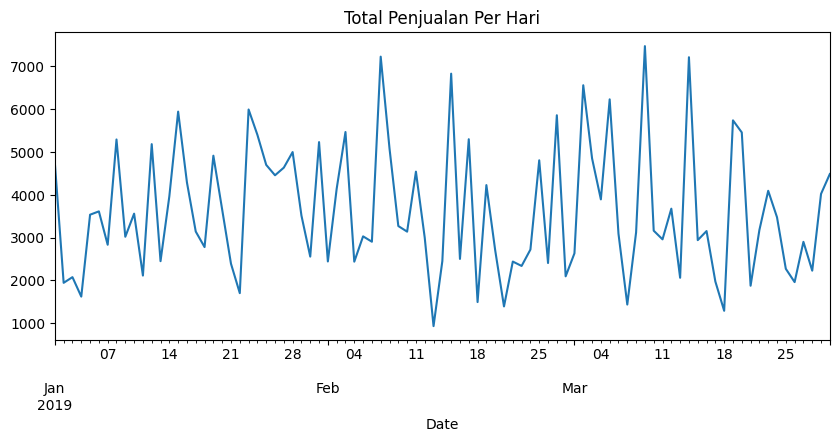

In [ ]:
ts.plot(figsize=(10,4), title="Total Penjualan Per Hari")


# STASIONERITAS

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -6.7085402463994805
p-value: 3.731247363509792e-09


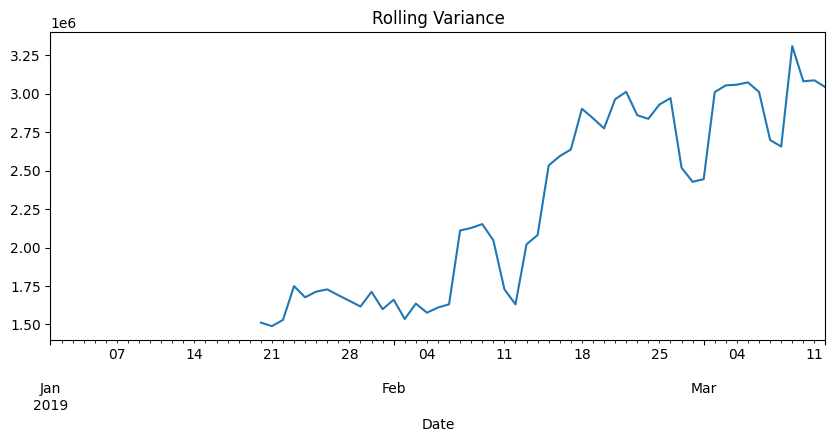

In [ ]:
import matplotlib.pyplot as plt

train.rolling(20).var().plot(figsize=(10,4), title="Rolling Variance")
plt.show()


In [ ]:
from scipy.stats import boxcox

train_boxcox, lam = boxcox(train)
print("Lambda:", lam)


Lambda: 0.3609213654399019


# CEK STASIONERITAS ULANG

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_boxcox)
print("ADF:", result[0])
print("p-value:", result[1])


ADF: -8.387461802807525
p-value: 2.4166718134619e-13


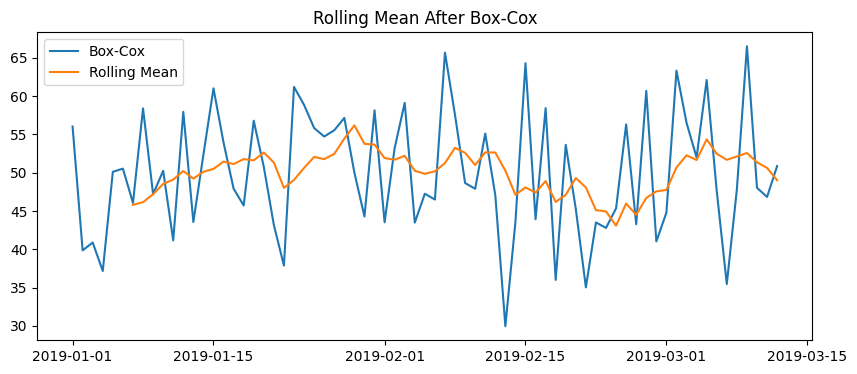

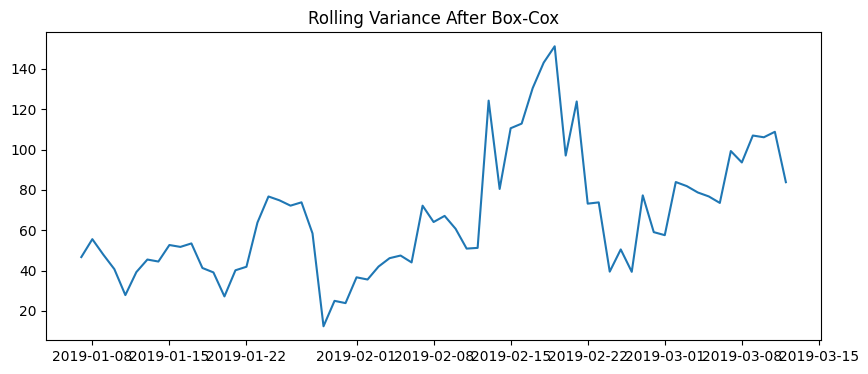

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

train_boxcox_series = pd.Series(train_boxcox, index=train.index)

rolling_mean = train_boxcox_series.rolling(7).mean()
rolling_var = train_boxcox_series.rolling(7).var()

plt.figure(figsize=(10,4))
plt.plot(train_boxcox_series, label='Box-Cox')
plt.plot(rolling_mean, label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean After Box-Cox")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(rolling_var)
plt.title("Rolling Variance After Box-Cox")
plt.show()


ini grafik setelah dilakukan box cox

# DIFFERENCING

In [ ]:
train_diff = train_boxcox_series.diff().dropna()


In [ ]:
train_log = np.log(train)


In [ ]:
train_bc, lam = boxcox(train)
train_bc

array([56.03584725, 39.85479453, 40.88152585, 37.16180708, 50.11663734,
       50.53213998, 46.05470884, 58.40412927, 47.19432372, 50.24731689,
       41.15921077, 57.94661374, 43.5619345 , 52.35247836, 61.01745334,
       53.92960714, 47.90988431, 45.71833864, 56.78569884, 50.75088297,
       43.15556757, 37.87033283, 61.21030915, 58.85298479, 55.83479242,
       54.72336057, 55.54339191, 57.1553656 , 50.00785863, 44.28234153,
       58.14777379, 43.51640835, 53.21486977, 59.12316338, 43.48194219,
       47.2526729 , 46.4937692 , 65.68256316, 57.5208583 , 48.65185849,
       47.8997989 , 55.11501693, 47.06058007, 29.93994359, 43.58162599,
       64.29954254, 43.9180974 , 58.42847004, 35.99889774, 53.63740508,
       45.24818989, 35.0204205 , 43.5011914 , 42.789119  , 45.3507366 ,
       56.31225898, 43.26665004, 60.68747529, 41.02431983, 44.78281496,
       63.32861231, 56.51541299, 51.98833831, 62.11087834, 47.61644605,
       35.45173791, 47.80862455, 66.51387374, 48.02880724, 46.83

In [ ]:
train_diff = np.diff(train_bc)     # setelah boxcox


# PLOT ACF PACF

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_diff)
print("ADF:", result[0])
print("p-value:", result[1])


ADF: -6.1228806601384465
p-value: 8.768975373275477e-08


In [ ]:
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(train_diff)

print("LM stat:", arch_test[0])
print("p-value:", arch_test[1])


LM stat: 10.547991984948409
p-value: 0.3937992717858011


In [ ]:
max_lag = min(40, len(train_diff) // 2)
plt.figure(figsize=(12, 5))

# Plot ACF
ax1 = plt.subplot(1, 2, 1)
plot_acf(train_diff, lags=max_lag, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')
ax1.grid(True)

# Plot PACF
ax2 = plt.subplot(1, 2, 2)
plot_pacf(train_diff, lags=max_lag, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('PACF')
ax2.grid(True)

plt.tight_layout()
plt.show()

<Figure size 400x100 with 0 Axes>

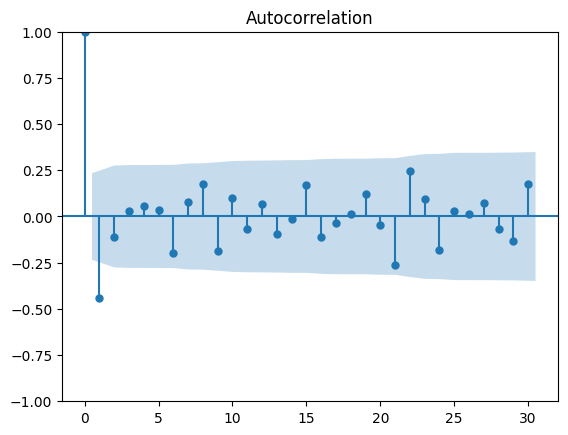

<Figure size 400x100 with 0 Axes>

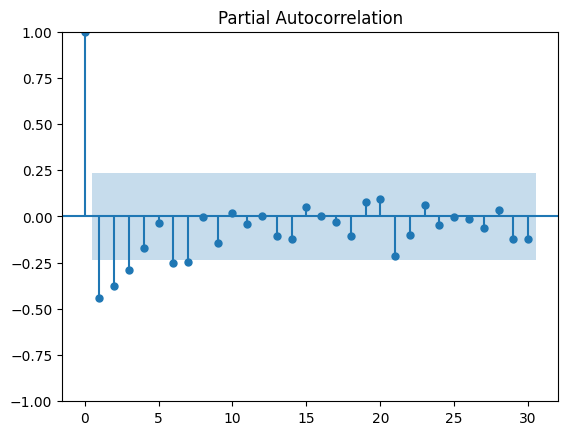

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(4,1))
plot_acf(train_diff, lags=30)
plt.show()

plt.figure(figsize=(4,1))
plot_pacf(train_diff, lags=30)
plt.show()


In [ ]:
model = ARIMA(train, order=(3, 1, 0))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   71
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -617.239
Date:                Mon, 08 Dec 2025   AIC                           1242.479
Time:                        07:41:15   BIC                           1251.473
Sample:                    01-01-2019   HQIC                          1246.051
                         - 03-12-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8104      0.153     -5.280      0.000      -1.111      -0.510
ar.L2         -0.6472      0.160     -4.034      0.000      -0.962      -0.333
ar.L3         -0.3886      0.109     -3.561      0.0

In [ ]:
model = ARIMA(train, order=(0, 1, 1))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   71
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -614.047
Date:                Mon, 08 Dec 2025   AIC                           1232.094
Time:                        07:41:53   BIC                           1236.591
Sample:                    01-01-2019   HQIC                          1233.880
                         - 03-12-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9998      0.185     -5.411      0.000      -1.362      -0.638
sigma2      2.298e+06   8.07e-08   2.85e+13      0.000     2.3e+06     2.3e+06
Ljung-Box (L1) (Q):                   0.19   Jarque-

# MODEL TERBAIKNYA

In [ ]:
model = ARIMA(train, order=(0, 1, 1))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   71
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -614.047
Date:                Mon, 08 Dec 2025   AIC                           1232.094
Time:                        07:42:01   BIC                           1236.591
Sample:                    01-01-2019   HQIC                          1233.880
                         - 03-12-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9998      0.185     -5.411      0.000      -1.362      -0.638
sigma2      2.298e+06   8.07e-08   2.85e+13      0.000     2.3e+06     2.3e+06
Ljung-Box (L1) (Q):                   0.19   Jarque-


[6] Uji White Noise (Ljung-Box)
p-value Ljung-Box: 0.5572
Kesimpulan: Residual WHITE NOISE (Model Bagus)

[7] Uji Heteroskedastisitas (ARCH)
p-value ARCH: 0.4146
Kesimpulan: Residual HOMOSKEDASTIS (Model Valid)

[8] Uji Normalitas Residual
p-value Shapiro: 0.0332
Kesimpulan: Residual TIDAK Normal


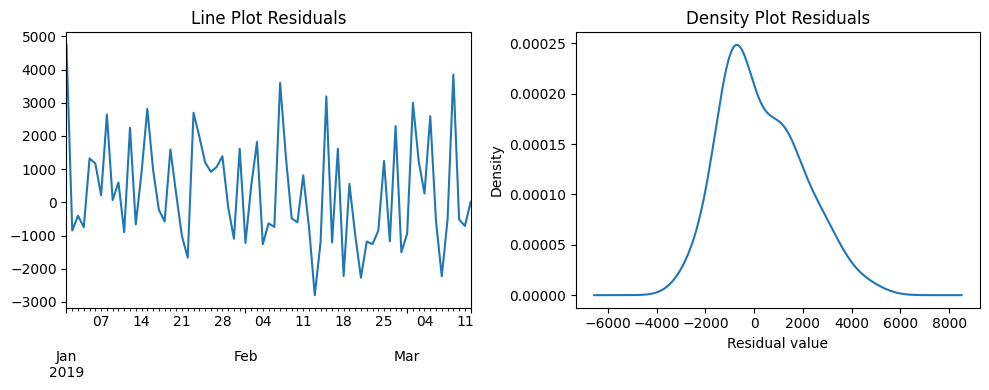

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy import stats
from statsmodels.stats.stattools import jarque_bera

# ambil residual dari model
residuals = model_fit.resid  # bisa ndarray atau Series tergantung versi/statsmodel

# pastikan residual adalah pandas Series (supaya .plot() tersedia)
if not isinstance(residuals, pd.Series):
    try:
        # coba pakai index dari data training bila ada (ganti 'train' sesuai variabelmu)
        residuals = pd.Series(residuals, index=train.index)
    except Exception:
        # kalau index tidak tersedia, buat Series tanpa index
        residuals = pd.Series(residuals)

# 6. Uji White Noise (Ljung-Box)
print("\n[6] Uji White Noise (Ljung-Box)")
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"p-value Ljung-Box: {lb_test['lb_pvalue'].values[0]:.4f}")
p_value_lb = lb_test['lb_pvalue'].values[0]
if p_value_lb > 0.05:
    print("Kesimpulan: Residual WHITE NOISE (Model Bagus)")
else:
    print("Kesimpulan: Residual TIDAK White Noise (Perlu perbaiki model)")

# 7. Uji Heteroskedastisitas (ARCH)
print("\n[7] Uji Heteroskedastisitas (ARCH)")
arch_test = het_arch(residuals)
print(f"p-value ARCH: {arch_test[1]:.4f}")
if arch_test[1] > 0.05:
    print("Kesimpulan: Residual HOMOSKEDASTIS (Model Valid)")
else:
    print("Kesimpulan: Residual HETEROSKEDASTIS (Mungkin perlu GARCH)")

# 8. Uji Normalitas (Shapiro-Wilk) - peringatan untuk sampel besar
print("\n[8] Uji Normalitas Residual")
n = len(residuals)
if n > 5000:
    # Shapiro tidak direkomendasikan untuk sample > 5000 (mungkin memakan memori atau memberikan hasil sensitif)
    print(f"Catatan: n = {n} > 5000. Shapiro-Wilk tidak direkomendasikan untuk sample besar.")
    # Alternatif: gunakan Jarque-Bera atau D'Agostino (normaltest)
    jb_stat, jb_p, _, _ = jarque_bera(residuals)
    print(f"Jarque-Bera p-value: {jb_p:.4f}")
    if jb_p > 0.05:
        print("Kesimpulan: Residual Berdistribusi NORMAL (menurut Jarque-Bera)")
    else:
        print("Kesimpulan: Residual TIDAK Normal (menurut Jarque-Bera)")
else:
    shapiro_test = stats.shapiro(residuals)
    print(f"p-value Shapiro: {shapiro_test.pvalue:.4f}")
    if shapiro_test.pvalue > 0.05:
        print("Kesimpulan: Residual Berdistribusi NORMAL")
    else:
        print("Kesimpulan: Residual TIDAK Normal")

# Visualisasi Residual
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
residuals.plot(title="Line Plot Residuals", legend=False)
plt.xlabel("")  # supaya label index tidak menggangu

plt.subplot(1,2,2)
residuals.plot(kind='kde', title="Density Plot Residuals", legend=False)
plt.xlabel("Residual value")

plt.tight_layout()
plt.show()


# FORECAST

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prediksi in-sample
fitted_values = model_fit.fittedvalues

# Hitung MAE
mae = mean_absolute_error(train, fitted_values)

# Hitung RMSE
rmse = np.sqrt(mean_squared_error(train, fitted_values))

# Hitung MAPE
mape = np.mean(np.abs((train - fitted_values) / train)) * 100

print("=== Evaluasi Model ARIMA(0,1,1) ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}%")

=== Evaluasi Model ARIMA(0,1,1) ===
MAE  : 1331.7259
RMSE : 1637.8668
MAPE : 41.7537%


api ARIMA(0,1,1) memang terlalu lemah untuk data kamu.

In [ ]:
forecast_30 = model_fit.forecast(steps=30)
print(forecast_30)

2019-03-13    3662.882767
2019-03-14    3662.882767
2019-03-15    3662.882767
2019-03-16    3662.882767
2019-03-17    3662.882767
2019-03-18    3662.882767
2019-03-19    3662.882767
2019-03-20    3662.882767
2019-03-21    3662.882767
2019-03-22    3662.882767
2019-03-23    3662.882767
2019-03-24    3662.882767
2019-03-25    3662.882767
2019-03-26    3662.882767
2019-03-27    3662.882767
2019-03-28    3662.882767
2019-03-29    3662.882767
2019-03-30    3662.882767
2019-03-31    3662.882767
2019-04-01    3662.882767
2019-04-02    3662.882767
2019-04-03    3662.882767
2019-04-04    3662.882767
2019-04-05    3662.882767
2019-04-06    3662.882767
2019-04-07    3662.882767
2019-04-08    3662.882767
2019-04-09    3662.882767
2019-04-10    3662.882767
2019-04-11    3662.882767
Freq: D, Name: predicted_mean, dtype: float64


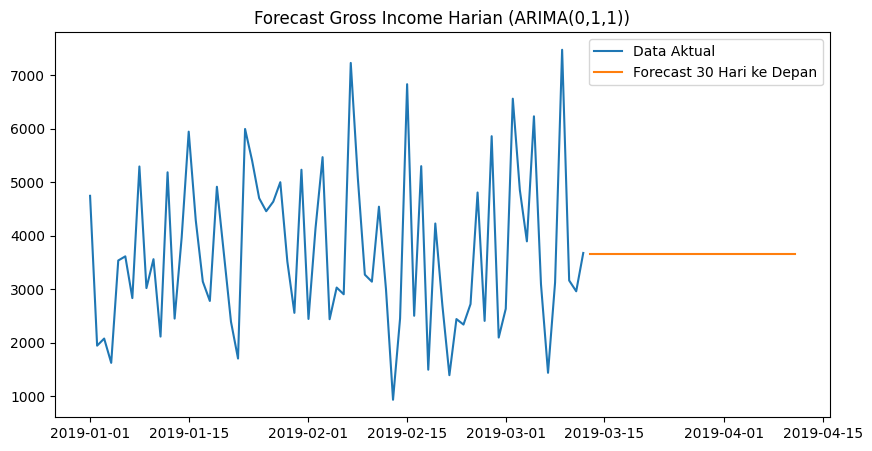

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Data Aktual')
plt.plot(forecast_30, label='Forecast 30 Hari ke Depan')
plt.legend()
plt.title('Forecast Gross Income Harian (ARIMA(0,1,1))')
plt.show()

# FORECAST ML

In [ ]:
# --- FORECASTING ARIMA ---
# Forecast untuk panjang data test
forecast_boxcox = model_fit.forecast(steps=len(test))
# Kembalikan skala (Inverse Box-Cox)
forecast_arima = inv_boxcox(forecast_boxcox, lam)
# Buat index tanggal agar sesuai plotting
forecast_arima = pd.Series(forecast_arima, index=test.index)

# Perbandingan GRU DAN LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Gabungkan train + test untuk dapat scaling yang konsisten
all_data = pd.concat([train, test])

# Normalisasi
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(all_data.values.reshape(-1,1))

# Pisahkan kembali
train_scaled = scaled_data[:len(train)]
test_scaled  = scaled_data[len(train):]

# Fungsi membuat window time series
def create_dataset(data, step=10):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

# Hyperparameter window (bisa disesuaikan)
TIME_STEP = 12

X_train, y_train = create_dataset(train_scaled, TIME_STEP)
X_test,  y_test  = create_dataset(test_scaled,  TIME_STEP)

# Reshape ke format RNN (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], TIME_STEP, 1)
X_test  = X_test.reshape(X_test.shape[0], TIME_STEP, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model = Sequential([
    GRU(64, return_sequences=False, activation='tanh', input_shape=(TIME_STEP, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - loss: 0.2455 - val_loss: 0.2022
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1785 - val_loss: 0.1676
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1343 - val_loss: 0.1362
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1213 - val_loss: 0.1099
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0791 - val_loss: 0.0941
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0574 - val_loss: 0.0990
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0669 - val_loss: 0.1135
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0699 - val_loss: 0.1038
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0592 - val_loss: 0.0970
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0545 - val_loss: 0.0951
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0559 - val_loss: 0.0950
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0611 - val_loss: 0.0947


In [ ]:
pred_scaled = model.predict(X_test)

# Balikkan scaling
pred = scaler.inverse_transform(pred_scaled)
y_true = scaler.inverse_transform(y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
mape = np.mean(np.abs((y_true - pred) / y_true)) * 100

print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape, "%")


RMSE: 1115.3725653915749
MAE : 1057.6034238281252
MAPE: 41.356550146683574 %


In [ ]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    LSTM(64, return_sequences=False, activation='tanh', input_shape=(TIME_STEP, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

history_lstm = model_lstm.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step - loss: 0.2038 - val_loss: 0.1726
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.1384 - val_loss: 0.1109
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0855 - val_loss: 0.0845
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0451 - val_loss: 0.1080
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0668 - val_loss: 0.1146
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0595 - val_loss: 0.0915
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0554 - val_loss: 0.0862
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0579 - val_loss: 0.0866
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.0584 - val_loss: 0.0861
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0532 - val_loss: 0.0880
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 0.0575 - val_loss: 0.0909
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 0.0567 - val_loss: 0

In [ ]:
# Prediksi menggunakan model LSTM
pred_scaled_lstm = model_lstm.predict(X_test)

# Kembalikan ke nilai asli (inverse transform)
pred_lstm = scaler.inverse_transform(pred_scaled_lstm)
y_true_lstm = scaler.inverse_transform(y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# MSE & RMSE
mse_lstm = mean_squared_error(y_true_lstm, pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)

# MAE
mae_lstm = mean_absolute_error(y_true_lstm, pred_lstm)

# MAPE (%)
mape_lstm = np.mean(np.abs((y_true_lstm - pred_lstm) / y_true_lstm)) * 100

print("=== Evaluasi Model LSTM ===")
print("MSE  :", mse_lstm)
print("RMSE :", rmse_lstm)
print("MAE  :", mae_lstm)
print("MAPE :", mape_lstm, "%")


=== Evaluasi Model LSTM ===
MSE  : 1977523.2441820304
RMSE : 1406.2443756979192
MAE  : 1226.1627500000002
MAPE : 52.29494336258217 %


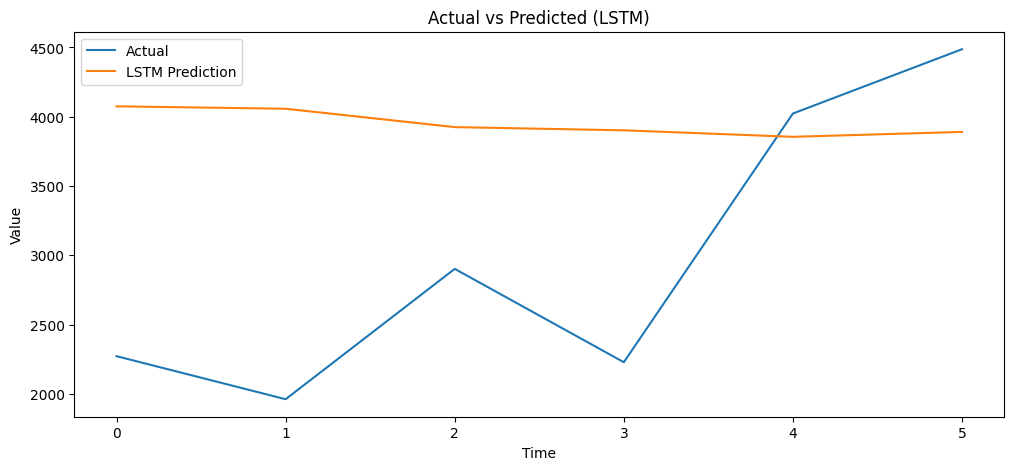

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_true_lstm, label='Actual')
plt.plot(pred_lstm, label='LSTM Prediction')
plt.title('Actual vs Predicted (LSTM)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


# ML

In [ ]:
look_back = 10
test_lstm = test.iloc[look_back:]


Kalau datamu harian dan berdurasi panjang, maka 30 sangat umum dipakai karena mewakili pola 1 bulan. Namun data test kita kurang dari iru sehingga memakai 10

In [ ]:
print("=== MODEL LSTM UNTUK FORECAST SALES ===")

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ============================================================
# 0. Pilih kolom target
# ============================================================
df = df[['Sales']]     # target prediksi
df = df.dropna()

# Pastikan index datetime (jika perlu)
df.index = pd.to_datetime(df.index)

# ============================================================
# 1. Train-test split (80-20)
# ============================================================
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]

train_data = train.values
test_data  = test.values

# ============================================================
# 2. Scaling
# ============================================================
scaler = MinMaxScaler(feature_range=(0,1))

scaled_all = scaler.fit_transform(df.values.reshape(-1,1))
scaled_train = scaled_all[:len(train)]
scaled_test  = scaled_all[len(train):]

# ============================================================
# 3. Sliding window function
# ============================================================
def create_sequences(dataset, look_back=30):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i+look_back, 0])
        y.append(dataset[i+look_back, 0])
    return np.array(X), np.array(y)

look_back = 30

# Build training sequences
X_train, y_train = create_sequences(scaled_train, look_back)

# Gabungkan akhir train sebelum test supaya tidak kosong
combined = np.concatenate((scaled_train[-look_back:], scaled_test), axis=0)
X_test, y_test = create_sequences(combined, look_back)

# Reshape sesuai input LSTM
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test  = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# ============================================================
# 4. Build LSTM model
# ============================================================
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

print("Training model LSTM...")
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

# ============================================================
# 5. Predict
# ============================================================
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)

# Buat series dengan index test
test_lstm = test.iloc[:len(pred)]
pred_series = pd.Series(pred.flatten(), index=test_lstm.index)

# ============================================================
# 6. Tampilkan hasil akhir
# ============================================================
print("\n=== HASIL PREDIKSI LSTM ===")
print(pred_series.head())


=== MODEL LSTM UNTUK FORECAST SALES ===
Training model LSTM...


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

=== HASIL PREDIKSI LSTM ===
Date
2019-03-12    532.565735
2019-03-12    179.898117
2019-03-12    384.759369
2019-03-12    632.525513
2019-03-12    177.727844
dtype: float32


=== MODEL LSTM UNTUK FORECAST SALES ===
Training model LSTM...


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

=== EVALUASI LSTM ===
MSE  : 57113.80755030381
RMSE : 238.984952560415
MAE  : 195.1691400268555


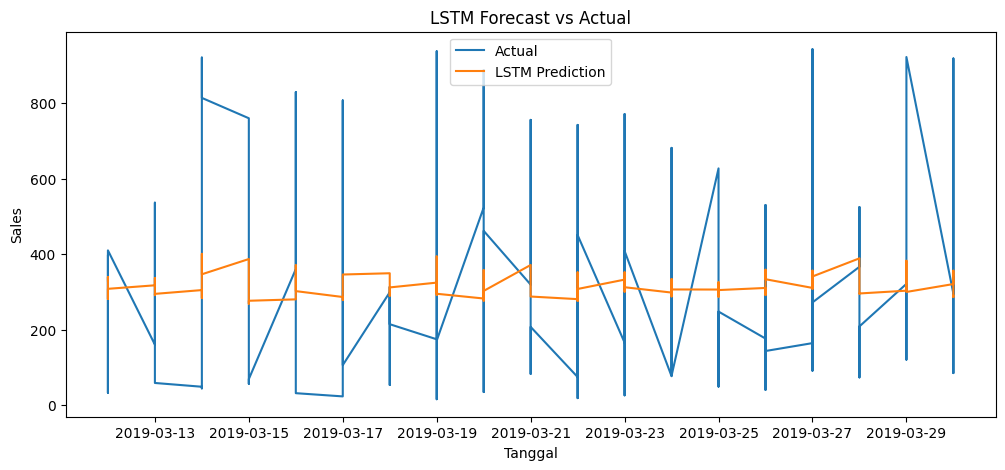


=== 5 Sample Hasil Prediksi ===
Date
2019-03-12    330.613068
2019-03-12    339.540253
2019-03-12    327.569641
2019-03-12    308.154785
2019-03-12    282.269257
dtype: float32


In [ ]:
print("=== MODEL LSTM UNTUK FORECAST SALES ===")

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ============================================================
# 0. Pilih kolom target
# ============================================================
df = df[['Sales']]     # Hanya target
df = df.dropna()
df.index = pd.to_datetime(df.index)

# ============================================================
# 1. Train-test split (80/20)
# ============================================================
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]

train_data = train.values
test_data  = test.values

# ============================================================
# 2. Scaling
# ============================================================
scaler = MinMaxScaler(feature_range=(0,1))
scaled_all = scaler.fit_transform(df.values)

scaled_train = scaled_all[:len(train)]
scaled_test  = scaled_all[len(train):]

# ============================================================
# 3. Sliding window
# ============================================================
def create_sequences(dataset, look_back=30):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i+look_back, 0])
        y.append(dataset[i+look_back, 0])
    return np.array(X), np.array(y)

look_back = 30

# Train seq
X_train, y_train = create_sequences(scaled_train, look_back)

# Test seq (menggabungkan bagian belakang train + test)
combined = np.concatenate((scaled_train[-look_back:], scaled_test), axis=0)
X_test, y_test = create_sequences(combined, look_back)

# Reshape untuk LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test  = X_test.reshape((X_test.shape[0], look_back, 1))

# ============================================================
# 4. Build LSTM model
# ============================================================
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

print("Training model LSTM...")
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

# ============================================================
# 5. Predict
# ============================================================
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)

# Buat series prediksi
test_lstm = test.iloc[:len(pred)]
pred_series = pd.Series(pred.flatten(), index=test_lstm.index)

# ============================================================
# 6. Evaluasi
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = test_lstm['Sales'].values

mse = mean_squared_error(y_true, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, pred)

print("\n=== EVALUASI LSTM ===")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)

# ============================================================
# 7. Plot hasil
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test_lstm.index, y_true, label='Actual')
plt.plot(pred_series.index, pred_series, label='LSTM Prediction')
plt.title("LSTM Forecast vs Actual")
plt.xlabel("Tanggal")
plt.ylabel("Sales")
plt.legend()
plt.show()

print("\n=== 5 Sample Hasil Prediksi ===")
print(pred_series.head())


In [ ]:
print("=== MODEL LSTM UNTUK FORECAST SALES ===")

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ============================================================
# 0. Pilih kolom target
# ============================================================
df = df[['Sales']]     # Hanya target
df = df.dropna()
df.index = pd.to_datetime(df.index)

# ============================================================
# 1. Train-test split (80/20)
# ============================================================
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]

train_data = train.values
test_data  = test.values

# ============================================================
# 2. Scaling
# ============================================================
scaler = MinMaxScaler(feature_range=(0,1))
scaled_all = scaler.fit_transform(df.values)

scaled_train = scaled_all[:len(train)]
scaled_test  = scaled_all[len(train):]

# ============================================================
# 3. Sliding window
# ============================================================
def create_sequences(dataset, look_back=30):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i+look_back, 0])
        y.append(dataset[i+look_back, 0])
    return np.array(X), np.array(y)

look_back = 30

# Train seq
X_train, y_train = create_sequences(scaled_train, look_back)

# Test seq (menggabungkan bagian belakang train + test)
combined = np.concatenate((scaled_train[-look_back:], scaled_test), axis=0)
X_test, y_test = create_sequences(combined, look_back)

# Reshape untuk LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test  = X_test.reshape((X_test.shape[0], look_back, 1))

# ============================================================
# 4. Build LSTM model
# ============================================================
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

print("Training model LSTM...")
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

# ============================================================
# 5. Predict
# ============================================================
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)

# Buat series prediksi
test_lstm = test.iloc[:len(pred)]
pred_series = pd.Series(pred.flatten(), index=test_lstm.index)

# ============================================================
# 6. Evaluasi
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = test_lstm['Sales'].values

mse = mean_squared_error(y_true, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, pred)

print("\n=== EVALUASI LSTM ===")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)

# ============================================================
# 7. Plot hasil
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test_lstm.index, y_true, label='Actual')
plt.plot(pred_series.index, pred_series, label='LSTM Prediction')
plt.title("LSTM Forecast vs Actual")
plt.xlabel("Tanggal")
plt.ylabel("Sales")
plt.legend()
plt.show()

print("\n=== 5 Sample Hasil Prediksi ===")
print(pred_series.head())


In [ ]:
#  Train Random Forest DENGAN TRANSFORMASI LOG
# 1. Transformasi y_train menggunakan log(1+x) untuk menangani nilai 0
y_train_log = np.log1p(y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Train model menggunakan data log
rf_model.fit(X_train, y_train_log)
pred_rf_log = rf_model.predict(X_test)

# 2. Inverse Transform: Kembalikan prediksi ke skala Sales asli
#    Gunakan exp(x) - 1
pred_rf_final = np.expm1(pred_rf_log)

# 3 Evaluasi Model (Menggunakan pred_rf_final)
mse_rf = mean_squared_error(y_test, pred_rf_final)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, pred_rf_final)

# Menghitung MAPE
y_test_non_zero = y_test[y_test != 0]
pred_rf_non_zero = pred_rf_final[y_test != 0]
mape_rf = np.mean(np.abs((y_test_non_zero - pred_rf_non_zero) / y_test_non_zero)) * 100

print("=== Evaluasi Random Forest (DENGAN LOG TRANSFORMATION) ===")
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("MAE  :", mae_rf)
print("MAPE :", mape_rf, "%")

# 4 Visualisasi Prediksi vs Actual (Dengan Sumbu X Tanggal)
# Gunakan pred_rf_final untuk visualisasi
pred_rf_series = pd.Series(pred_rf_final, index=y_test.index)

plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(pred_rf_series, label='RF Prediction (Log Transformed)')

plt.legend()
plt.title("Random Forest Prediction vs Actual (Setelah Log Transformation)")
plt.xlabel("Tanggal")
plt.ylabel("Sales")
plt.show()

NameError: name 'RandomForestRegressor' is not defined

In [ ]:
#  Train Random Forest DENGAN TRANSFORMASI LOG
from sklearn.ensemble import RandomForestRegressor

# 1. Transformasi y_train menggunakan log(1+x) untuk menangani nilai 0
y_train_log = np.log1p(y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Train model menggunakan data log
rf_model.fit(X_train, y_train_log)
pred_rf_log = rf_model.predict(X_test)

# 2. Inverse Transform: Kembalikan prediksi ke skala Sales asli
#    Gunakan exp(x) - 1
pred_rf_final = np.expm1(pred_rf_log)

# 3 Evaluasi Model (Menggunakan pred_rf_final)
mse_rf = mean_squared_error(y_test, pred_rf_final)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, pred_rf_final)

# Menghitung MAPE
y_test_non_zero = y_test[y_test != 0]
pred_rf_non_zero = pred_rf_final[y_test != 0]
mape_rf = np.mean(np.abs((y_test_non_zero - pred_rf_non_zero) / y_test_non_zero)) * 100

print("=== Evaluasi Random Forest (DENGAN LOG TRANSFORMATION) ===")
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("MAE  :", mae_rf)
print("MAPE :", mape_rf, "%")

# 4 Visualisasi Prediksi vs Actual (Dengan Sumbu X Tanggal)
# Gunakan pred_rf_final untuk visualisasi
pred_rf_series = pd.Series(pred_rf_final, index=y_test.index)

plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(pred_rf_series, label='RF Prediction (Log Transformed)')

plt.legend()
plt.title("Random Forest Prediction vs Actual (Setelah Log Transformation)")
plt.xlabel("Tanggal")
plt.ylabel("Sales")
plt.show()

ValueError: Found array with dim 3. RandomForestRegressor expected <= 2.

Model Anda sudah berhasil dalam hal improving (memperbaiki) kinerja, tetapi belum berhasil dalam hal predicting (memprediksi) secara akurat.

In [ ]:
# ============================
# IMPORT LIBRARY
# ============================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# 1. Transformasi LOG
# ============================
y_train_log = np.log1p(y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model dengan y_log
rf_model.fit(X_train, y_train_log)
pred_rf_log = rf_model.predict(X_test)

# ============================
# 2. INVERSE TRANSFORM
# ============================
pred_rf_final = np.expm1(pred_rf_log)

# ============================
# 3. EVALUASI MODEL
# ============================
mse_rf = mean_squared_error(y_test, pred_rf_final)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, pred_rf_final)

# Hitung MAPE (hilangkan target yang 0)
y_test_non_zero = y_test[y_test != 0]
pred_rf_non_zero = pred_rf_final[y_test != 0]
mape_rf = np.mean(np.abs((y_test_non_zero - pred_rf_non_zero) / y_test_non_zero)) * 100

print("=== Evaluasi Random Forest (DENGAN LOG TRANSFORMATION) ===")
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("MAE  :", mae_rf)
print("MAPE :", mape_rf, "%")

# ============================
# 4. VISUALISASI
# ============================
pred_rf_series = pd.Series(pred_rf_final, index=y_test.index)

plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(pred_rf_series, label='RF Prediction (Log Transformed)')
plt.legend()
plt.title("Random Forest Prediction vs Actual (Setelah Log Transformation)")
plt.xlabel("Tanggal")
plt.ylabel("Sales")
plt.show()


ValueError: Found array with dim 3. RandomForestRegressor expected <= 2.